# Recurrent Neural Network

## Part 1 - Data Preprocessing

### Importing the libraries

In [ ]:
!pipinstall pip==23.0.1
!pip install setuptools==65.5.0 "wheel<0.40.0"
!pip install d2l==1.0.0

/bin/bash: line 1: pipinstall: command not found


In [ ]:
# Here I import the necessray libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importing the training set

In [ ]:
dataset_train = pd.read_csv('Google_Stock_Price_Train.csv') # change the path
training_set = dataset_train.iloc[:, 1:2].values

### Feature Scaling

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
# from sklearn.preprocessing import StandardScaler

# # I tried standard Scaler to see if the model improved
# sc = StandardScaler()

# # Here I fit and transform the training set
# training_set_scaled = sc.fit_transform(training_set)

# # Next I load or define the test set
# test_set = pd.read_csv('Google_Stock_Price_Test.csv').iloc[:, 1:2].values

# # Finally I transformed the data
# test_set_scaled = sc.transform(test_set)

### Creating a data structure with 60 timesteps and 1 output

In [ ]:
X_train = []
y_train = []
for i in range(60, 1258):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

### Reshaping

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

## Part 2 - Building and Training the RNN

### Importing the Keras libraries and packages

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

### Initialising the RNN

In [ ]:
regressor = Sequential()

The purpose of the following lines is to introduce you to LSTM.

### Adding the first LSTM layer (units=50) and some Dropout (0.2) regularisation

In [ ]:
# Here I initialize the first LSTM layer (units=50) and Dropout regularisation(0.2)
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Adding a second LSTM layer (units=50) and some Dropout (0.2) regularisation

In [ ]:
# Here I add the second LSTM layer (units=50)and Dropout regularisation(0.2)
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

### Adding a third LSTM layer (units=50) and some Dropout (0.2) regularisation

In [ ]:
# Here I add the third LSTM layer (units=50)and Dropout regularisation(0.2)
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

### Adding a fourth LSTM layer (units=50) and some Dropout (0.2) regularisation

In [ ]:
# Here I add the third LSTM layer (units=50)and Dropout regularisation(0.2)
regressor.add(LSTM(units=50, return_sequences=False))
regressor.add(Dropout(0.2))

### Adding the output layer

In [ ]:
# Here I add the outputlayer for my regressor with(1 untit for contrinius output)
regressor.add(Dense(units=1))

### Compiling the RNN with appropriate optimizer and loss function

In [ ]:
# Next I compile my RNN (using MSE)
regressor.compile(optimizer='adam', loss='mean_squared_error')

### Fitting the RNN to the Training set

In [ ]:
# Now I fit the RNN for training(epochs=50) (batch_size=100)
regressor.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1542
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0863
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0828
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0792
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0764
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0773
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0809
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0796
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0778
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0807
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0763
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0746
Epoch 13/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0770
Epoch 14/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0725
Epoch 15/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0763
Epoc

## Part 3 - Making the predictions and visualising the results

### Getting the real stock price of 2017

In [ ]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')   # change path
real_stock_price = dataset_test.iloc[:, 1:2].values

### Getting the predicted stock price of 2017

In [ ]:
# First I prept the dataset
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

# Next I prepared X_test for LSTM model
X_test = []
for i in range(60, len(inputs)):  # Adjust the range to process all inputs
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)  # Reshape for LSTM input

# Finally I predicted the stock prices using the regressor
predictions = regressor.predict(X_test)

# Here I 'inverse transform' the predictions to get actual stock prices
predictions = predictions.reshape(-1, 1)  # Had to make it 2D array before inverse transforming
predictions = sc.inverse_transform(predictions)  # Unding scaling




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


### Visualising the results

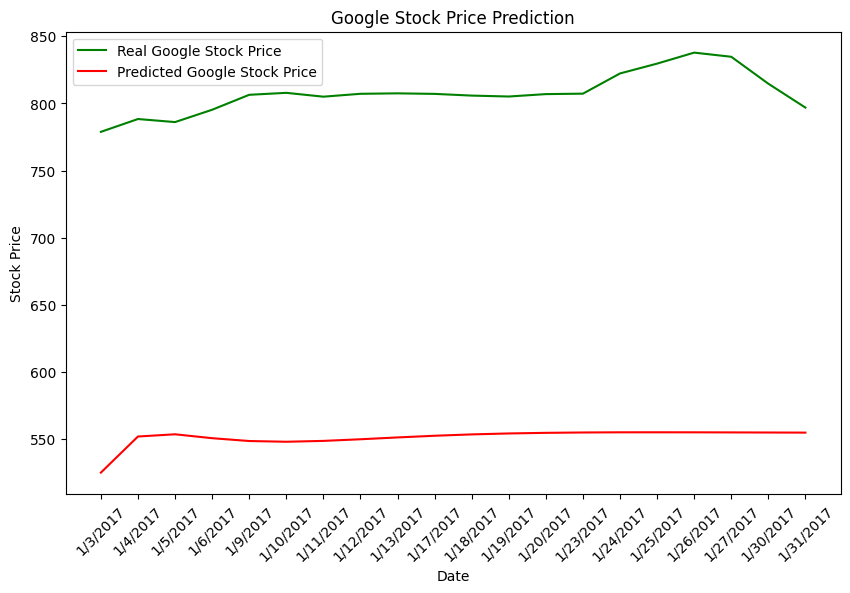

In [ ]:
# plot Real Google Stock Price over time and Predicted Google Stock Price over time in the same plot/figure

import matplotlib.pyplot as plt

# I was not sure if the open or close price should be used
real_stock_price = dataset_test['Open'].values  # Actual stock prices for Google in the test set
dates = dataset_test['Date'].values  # Here I extracted the 'Date' column for x-axis labels

# Here I plot both the real and predicted stock prices
plt.figure(figsize=(10,6))
plt.plot(dates, real_stock_price, color='green', label='Real Google Stock Price')
plt.plot(dates, predictions[:len(dates)], color='red', label='Predicted Google Stock Price')

# Making things pretty with titles and labels
plt.title('Google Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.xticks(rotation=45)  # I rotated dates on x-axis for better readability
plt.legend()

# Finally I display my plot
plt.show()
